In [43]:
#&&&&&&&&&&&&&&&    Importar librería    &&&&&&&&&&&&&&&
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# librería Parte 2
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler


from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors 


### Parte 1: Análisis Exploratorio y Visualización (3 puntos)

#### 1.1 Exploración Inicial con Pandas y NumPy (1 punto)
* Carga el dataset y muestra las primeras 10 filas
* Genera estadísticas descriptivas completas de las variables numéricas
* Identifica y maneja valores nulos o inconsistentes
* Calcula la correlación entre variables numéricas usando NumPy
* Identifica outliers en horas_estudio_semanal y monto_inversion

In [3]:
#&&&&&&&&&&&&&&&    Reproducibidad   &&&&&&&&&&&&&&&    
random_state = 42
np.random.seed(random_state)

In [4]:
#&&&&&&&&&&&&&&&    Cargar datos   &&&&&&&&&&&&&&&  
df=pd.read_csv(r"c:\Users\Jocelyn Matus Ancavi\Desktop\GIT\Data-science-Machine-Learning\02. Material de apoyo - Estudiantes_edutech.csv")  
pd.set_option('display.max_columns',None) # mostrar todas las columnas
# para ver la forma de los datos 
df.head(10)
df.tail()

,id_estudiante,nombre,edad,genero,pais,horas_estudio_semanal,sesiones_totales,tareas_completadas,tareas_totales,participacion_foros,promedio_evaluaciones,dispositivo_principal,horario_estudio,nivel_educacion,experiencia_previa,monto_inversion,plataforma_origen,curso_completado,puntaje_satisfaccion
495,496,Estudiante_496,36,Otro,Argentina,3,20,41,50,18,69.68,Desktop,Tarde,Pregrado,Sí,3019,Referido,0,3.6
496,497,Estudiante_497,49,Otro,Chile,14,146,25,50,27,70.76,Tablet,Noche,Secundaria,Sí,953,Facebook,0,4.3
497,498,Estudiante_498,18,Masculino,Chile,16,60,43,50,39,68.89,Mobile,Madrugada,Secundaria,No,1591,Facebook,1,6.4
498,499,Estudiante_499,22,Otro,Colombia,10,191,13,50,83,78.13,Tablet,Madrugada,Pregrado,Sí,3553,Facebook,0,6.0
499,500,Estudiante_500,62,Femenino,Perú,29,134,36,50,96,45.44,Desktop,Mañana,Secundaria,Sí,2703,Facebook,0,5.0


In [5]:
#&&&&&&&&&&&&&&&    Exploración de datos    &&&&&&&&&&&&&&&
df. info()
print(f'\nFilas:{df.shape[0]}| Columnas:{list(df.columns)}')
print("\n ---- Tipos de datos ----")
print(df.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_estudiante          500 non-null    int64  
 1   nombre                 500 non-null    object 
 2   edad                   500 non-null    int64  
 3   genero                 500 non-null    object 
 4   pais                   500 non-null    object 
 5   horas_estudio_semanal  500 non-null    int64  
 6   sesiones_totales       500 non-null    int64  
 7   tareas_completadas     500 non-null    int64  
 8   tareas_totales         500 non-null    int64  
 9   participacion_foros    500 non-null    int64  
 10  promedio_evaluaciones  500 non-null    float64
 11  dispositivo_principal  500 non-null    object 
 12  horario_estudio        500 non-null    object 
 13  nivel_educacion        500 non-null    object 
 14  experiencia_previa     500 non-null    object 
 15  monto_

In [8]:
#&&&&&&&&&&&&&&&    Data profiling   #&&&&&&&&&&&&&&&    

In [6]:
# Clasificación de variables por tipo 
# (soporta bool, datetime, category, etc.)
def clasificar_columna(dtype):
    if   pd.api.types.is_bool_dtype(dtype):
        #bool debe revisarse antes que numeric,
        #porque pd.api.types.is_numeric_dtype() devuelve True también para columnas booleanas (por dentro se guardan como 0 o 1)
        return 'booleana'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'fecha/hora'
    elif isinstance(dtype, pd.CategoricalDtype):
        return 'categórica (category)'
    elif pd.api.types.is_numeric_dtype(dtype):
        return 'cuantitativa'
    elif pd.api.types.is_object_dtype(dtype) or pd.api.types.is_string_dtype(dtype):
        return 'categórica (texto)'
    else:
        return 'otro/desconocido'

clasificacion = df.dtypes.apply(clasificar_columna)
print(clasificacion.value_counts())
print("Total clasificado:",len(clasificacion),"| Total columnas:", df.shape[1])

# Listas derivadas de la clasificación 
# reemplazan el select_dtypes manual
categoricas   = clasificacion[clasificacion.str.startswith('categórica')].index.tolist()
cuantitativas = clasificacion[clasificacion=='cuantitativa'].index.tolist()

cuantitativa          11
categórica (texto)     8
Name: count, dtype: int64
Total clasificado: 19 | Total columnas: 19


In [7]:
def es_binaria(col):
    serie = df[col].dropna()
    if pd.api.types.is_bool_dtype(df[col]):
        return True
    return serie.nunique() <=2 and set(serie.unique()).issubset({0, 1})

cuantitativas_no_binarias = [c for c in cuantitativas if not es_binaria(c)]

In [8]:
total_clasi= len(categoricas) + len(cuantitativas)

if total_clasi==df.shape[1]:
    print("Coincide, todas las columnas quedaron clasificadas")
else:
    faltantes = set(df.columns)-set(categoricas)-set(cuantitativas)
    print("No coincide, Columnas sin clasificar como categórica o cuantitativa:",faltantes)
    print(df[list(faltantes)].dtypes)

Coincide, todas las columnas quedaron clasificadas


In [9]:
#&&&&&&&&&&&&&&&    Identificación de variable       &&&&&&&&&&&&&&& 
print("=== Variables cuantitativas y categóricas ===")
print("Cuantitativas:",cuantitativas)
print("Categóricas:  ",categoricas)

=== Variables cuantitativas y categóricas ===
Cuantitativas: ['id_estudiante', 'edad', 'horas_estudio_semanal', 'sesiones_totales', 'tareas_completadas', 'tareas_totales', 'participacion_foros', 'promedio_evaluaciones', 'monto_inversion', 'curso_completado', 'puntaje_satisfaccion']
Categóricas:   ['nombre', 'genero', 'pais', 'dispositivo_principal', 'horario_estudio', 'nivel_educacion', 'experiencia_previa', 'plataforma_origen']


algo importante curso_completado esta como numerica pero es bool 

> **Buena práctica: diccionario de etiquetas para visualización**

Como se van hacer gráficos de sns y plt es bueno hacer un diccionario de etiqueta para que en los label de las variables queden sin "_" y en términos de costo computacional tambien se recomienda y toma mayor peso cuando los data set son mas grandes, Además así tampoco se modifica el dataframe original.

In [ ]:
# Nuevas variables derivadas (partes 2)
df['tasa_completitud']  = (df['tareas_completadas']/df['tareas_totales'])*100
df['estudiante_activo'] = (df['sesiones_totales']>50).astype(int)

# Etiquetas legibles 
Etiquetas = {
    "id_estudiante"    : "ID Estudiante",
    "nombre"           : "Nombre",
    "edad"             : "Edad",
    "genero"           : "Género",
    "pais"             : "País",
    "horas_estudio_semanal" : "Horas de Estudio Semanal",
    "sesiones_totales"      : "Sesiones Totales",
    "tareas_completadas"    : "Tareas Completadas",
    "tareas_totales"        : "Tareas Totales",
    "participacion_foros"   : "Participación en Foros",
    "promedio_evaluaciones" : "Promedio de Evaluaciones",
    "dispositivo_principal" : "Dispositivo Principal",
    "horario_estudio"     : "Horario de Estudio",
    "nivel_educacion"     : "Nivel de Educación",
    "experiencia_previa"  : "Experiencia Previa",
    "monto_inversion"     : "Monto de Inversión",
    "plataforma_origen"   : "Plataforma de Origen",
    "curso_completado"    : "Curso Completado",
    "puntaje_satisfaccion": "Puntaje de Satisfacción",
    #Variables parte 2
    'tasa_completitud'    :  "Tasa de completitud",
    'estudiante_activo'   :  "Estudiante activo"
}
df_plot = df.rename(columns=Etiquetas)

In [27]:
categoricas_relevantes = [c for c in categoricas if c != 'nombre']

for col in categoricas_relevantes:
    print(f"\n---- {Etiquetas.get(col, col)} ----")
    print("Valores únicos:", df[col].unique())
    print("\nConteo:")
    print(df[col].value_counts())
#ver desbalances


---- Género ----
Valores únicos: ['Otro' 'Femenino' 'Masculino']

Conteo:
genero
Masculino    185
Otro         158
Femenino     157
Name: count, dtype: int64

---- País ----
Valores únicos: ['Argentina' 'Colombia' 'México' 'Perú' 'Chile' 'España']

Conteo:
pais
México       89
Chile        88
Perú         87
España       81
Argentina    80
Colombia     75
Name: count, dtype: int64

---- Dispositivo Principal ----
Valores únicos: ['Mobile' 'Tablet' 'Desktop']

Conteo:
dispositivo_principal
Desktop    173
Tablet     170
Mobile     157
Name: count, dtype: int64

---- Horario de Estudio ----
Valores únicos: ['Noche' 'Tarde' 'Mañana' 'Madrugada']

Conteo:
horario_estudio
Mañana       134
Noche        127
Tarde        122
Madrugada    117
Name: count, dtype: int64

---- Nivel de Educación ----
Valores únicos: ['Posgrado' 'Pregrado' 'Secundaria']

Conteo:
nivel_educacion
Posgrado      177
Pregrado      167
Secundaria    156
Name: count, dtype: int64

---- Experiencia Previa ----
Valores únic

In [28]:
#&&&&&&&&&&&&&&&    Detección de outliers   &&&&&&&&&&&&&&&

In [29]:
# Verificación de valores nulos y duplicados 
print("Valores nulos por columna:\n",df.isnull().sum())
##print("\nFilas duplicadas:", df.duplicated().sum())
print("\nDuplicados por id estudiante:",df['id_estudiante'].duplicated().sum())
print("Duplicados por nombre:",df['nombre'].duplicated().sum())

Valores nulos por columna:
 id_estudiante            0
nombre                   0
edad                     0
genero                   0
pais                     0
horas_estudio_semanal    0
sesiones_totales         0
tareas_completadas       0
tareas_totales           0
participacion_foros      0
promedio_evaluaciones    0
dispositivo_principal    0
horario_estudio          0
nivel_educacion          0
experiencia_previa       0
monto_inversion          0
plataforma_origen        0
curso_completado         0
puntaje_satisfaccion     0
tasa_completitud         0
estudiante_activo        0
dtype: int64

Duplicados por id estudiante: 0
Duplicados por nombre: 0


In [30]:
# valores ceros no bool
ancho = max(len(col) for col in cuantitativas_no_binarias) + 1  # +1 por los ':'
for col in cuantitativas_no_binarias:
    n   = (df[col] == 0).sum()
    pct = (df[col] == 0).mean()*100
    print(f"{col + ':':<{ancho}} {n:>4} ceros ({pct:.1f}%)")

id_estudiante:            0 ceros (0.0%)
edad:                     0 ceros (0.0%)
horas_estudio_semanal:    0 ceros (0.0%)
sesiones_totales:         0 ceros (0.0%)
tareas_completadas:       7 ceros (1.4%)
tareas_totales:           0 ceros (0.0%)
participacion_foros:      5 ceros (1.0%)
promedio_evaluaciones:    0 ceros (0.0%)
monto_inversion:          0 ceros (0.0%)
puntaje_satisfaccion:     0 ceros (0.0%)


1.4% hay de tareas no completadas y un 1% de cero participacion en foros 

In [ ]:
# valores fueras de rango 
print("\n---- Revisión variables dentro del rango ----\n")
chequeos = [
    ("Filas con tareas completadas > tareas_totales", (df['tareas_completadas'] > df['tareas_totales']).sum()),
    ("Edades fuera de rango 18-100", ((df['edad'] < 18) | (df['edad'] > 100)).sum()),
    ("Puntaje satisfacción fuera de rango 0-10", ((df['puntaje_satisfaccion'] < 0) | (df['puntaje_satisfaccion'] > 10)).sum()),
    ("Participación de foros fuera de rango 0-100", ((df['participacion_foros'] < 0) | (df['participacion_foros'] > 100)).sum()),
    ("Promedio de evaluaciones fuera de 0-100", ((df['promedio_evaluaciones'] < 0) | (df['promedio_evaluaciones'] > 100)).sum()),
]
# Variables que por definición, no pueden ser negativas
no_negativas = ['horas_estudio_semanal','sesiones_totales','tareas_completadas','tareas_totales','participacion_foros','monto_inversion']
for col in no_negativas:
    chequeos.append((f"{Etiquetas.get(col, col)} con valores negativos", (df[col] < 0).sum()))
# Variable binaria debe ser solo 0 o 1 
chequeos.append(("Curso completado con valores fuera de {0,1}", (~df['curso_completado'].isin([0, 1])).sum()))
chequeos.append(("Estudiante activo con valores fuera de {0,1}", (~df['estudiante_activo'].isin([0, 1])).sum()))
chequeos.append((f"{Etiquetas.get('horas_estudio_semanal', 'horas_estudio_semanal')} > 168 (imposible)", (df['horas_estudio_semanal'] > 168).sum()))

ancho = max(len(etiqueta) for etiqueta, _ in chequeos) + 1  # +1 por los ':'
for etiqueta, valor in chequeos:
    print(f"{etiqueta + ':':<{ancho}} {valor:>3}")


---- Revisión variables dentro del rango ----

Filas con tareas completadas > tareas_totales:    0
Edades fuera de rango 18-100:                     0
Puntaje satisfacción fuera de rango 0-10:         0
Participación de foros fuera de rango 0-100:      0
Promedio de evaluaciones fuera de 0-100:          0
Horas de Estudio Semanal con valores negativos:   0
Sesiones Totales con valores negativos:           0
Tareas Completadas con valores negativos:         0
Tareas Totales con valores negativos:             0
Participación en Foros con valores negativos:     0
Monto de Inversión con valores negativos:         0
Curso completado con valores fuera de {0,1}:      0
Estudiante activo con valores fuera de {0,1}:     0
Horas de Estudio Semanal > 168 (imposible):       0


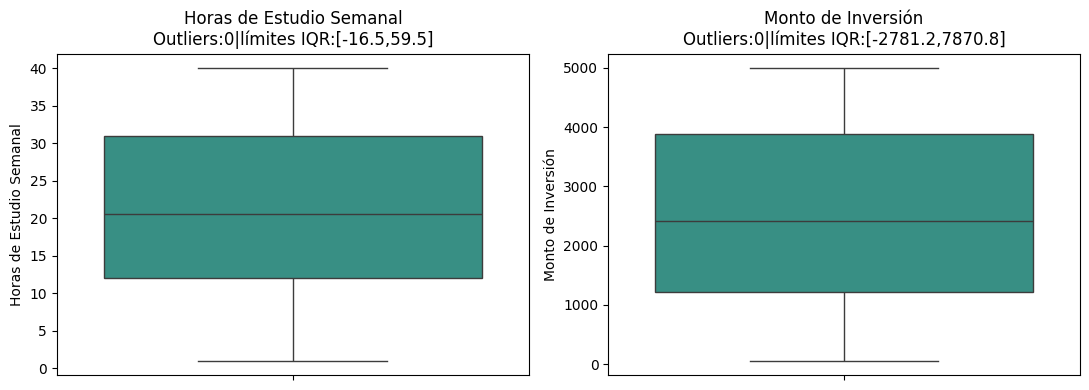

In [32]:
# Identificación de outliers con método IQR 
# para horas estudio semanal y monto inversión
def detectar_outliers_iqr(serie):
    q1,q3 = np.percentile(serie,[25,75])
    iqr = q3-q1
    lim_inf, lim_sup = q1-1.5*iqr,q3+1.5*iqr
    outliers = serie[(serie<lim_inf)|(serie>lim_sup)]
    return outliers,lim_inf,lim_sup

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes,['horas_estudio_semanal','monto_inversion']):
    outliers, li,ls=detectar_outliers_iqr(df[col])
    sns.boxplot(y=df[col],ax=ax,color='#2A9D8F')
    ax.set_title(f'{Etiquetas.get(col,col)}\nOutliers:{len(outliers)}|límites IQR:[{li:.1f},{ls:.1f}]')
    ax.set_ylabel(Etiquetas.get(col,col))
plt.tight_layout()
plt.show()

Interpretación boxplot, no se ven valores fuera de los bigotes, por lo que no hay valores extremos

In [33]:
print("\n---- Estadísticas descriptivas de las variables numericas ----")

num_col_sin_id = [c for c in df.select_dtypes(include=[np.number]).columns if c !='id_estudiante']
df[num_col_sin_id].describe().T


---- Estadísticas descriptivas de las variables numericas ----


,count,mean,std,min,25%,50%,75%,max
edad,500.0,41.98000,13.800598,18.00,31.00,43.00,53.0000,65.00
horas_estudio_semanal,500.0,20.90200,11.312486,1.00,12.00,20.50,31.0000,40.00
sesiones_totales,500.0,99.65800,58.079527,1.00,48.00,102.00,149.2500,200.00
tareas_completadas,500.0,25.26400,14.359202,0.00,14.00,24.50,38.0000,50.00
tareas_totales,500.0,50.00000,0.000000,50.00,50.00,50.00,50.0000,50.00
participacion_foros,500.0,49.77800,28.892807,0.00,25.00,48.00,75.0000,100.00
promedio_evaluaciones,500.0,71.15994,17.358748,40.03,56.03,72.14,85.7725,99.98
monto_inversion,500.0,2508.95600,1467.201453,61.00,1213.25,2413.50,3876.2500,4992.00
curso_completado,500.0,0.14600,0.353460,0.00,0.00,0.00,0.0000,1.00
puntaje_satisfaccion,500.0,5.35980,1.728496,1.00,4.20,5.30,6.5000,10.00


Dataset no tiene valores nulos, ni duplicados.
a modo de ejemplo muestro a continuación código de depuración como buena práctica.
* df = df.dropna()      # elimina filas con nulos si existieran y antes de aplicarlo hay que ver si esto es acorde al contexto
* df = df.drop_duplicates(subset='id_estudiante') # elimina duplicados de estudiantes

Con respecto a los outliers:
* horas estudio semanal está en el rango de 1-40
* monto inversion está en el rango 61-4.992
Ambos muestran que **no** están fuera de los límites de Tukey.(Q1 − 1.5·IQR, Q3 + 1.5·IQR).
Igual de los boxplot se ve que no hay valores fuera de los bigotes 

---
Antes de calcula correlación, es necesario revisar como distribuyen las variables entre otras cosas, para saber si se debe aplicar Pearson (y hacer inferencia sobre él)  o Spearman, ya que Pearson asume:
 * variables cuantitativas continuas
 * relación lineal
 * normalidad de ambas variables
 * observaciones independientes

Si esto no se cumple lo adecuado es usar Spearman.
dejo referencia, página 9: https://revistes.ub.edu/index.php/REIRE/article/view/reire2019.12.228245/29310

>**Buena práctica hacer una grilla dinámica**
Se consigue que se ajuste al n° real de variables  

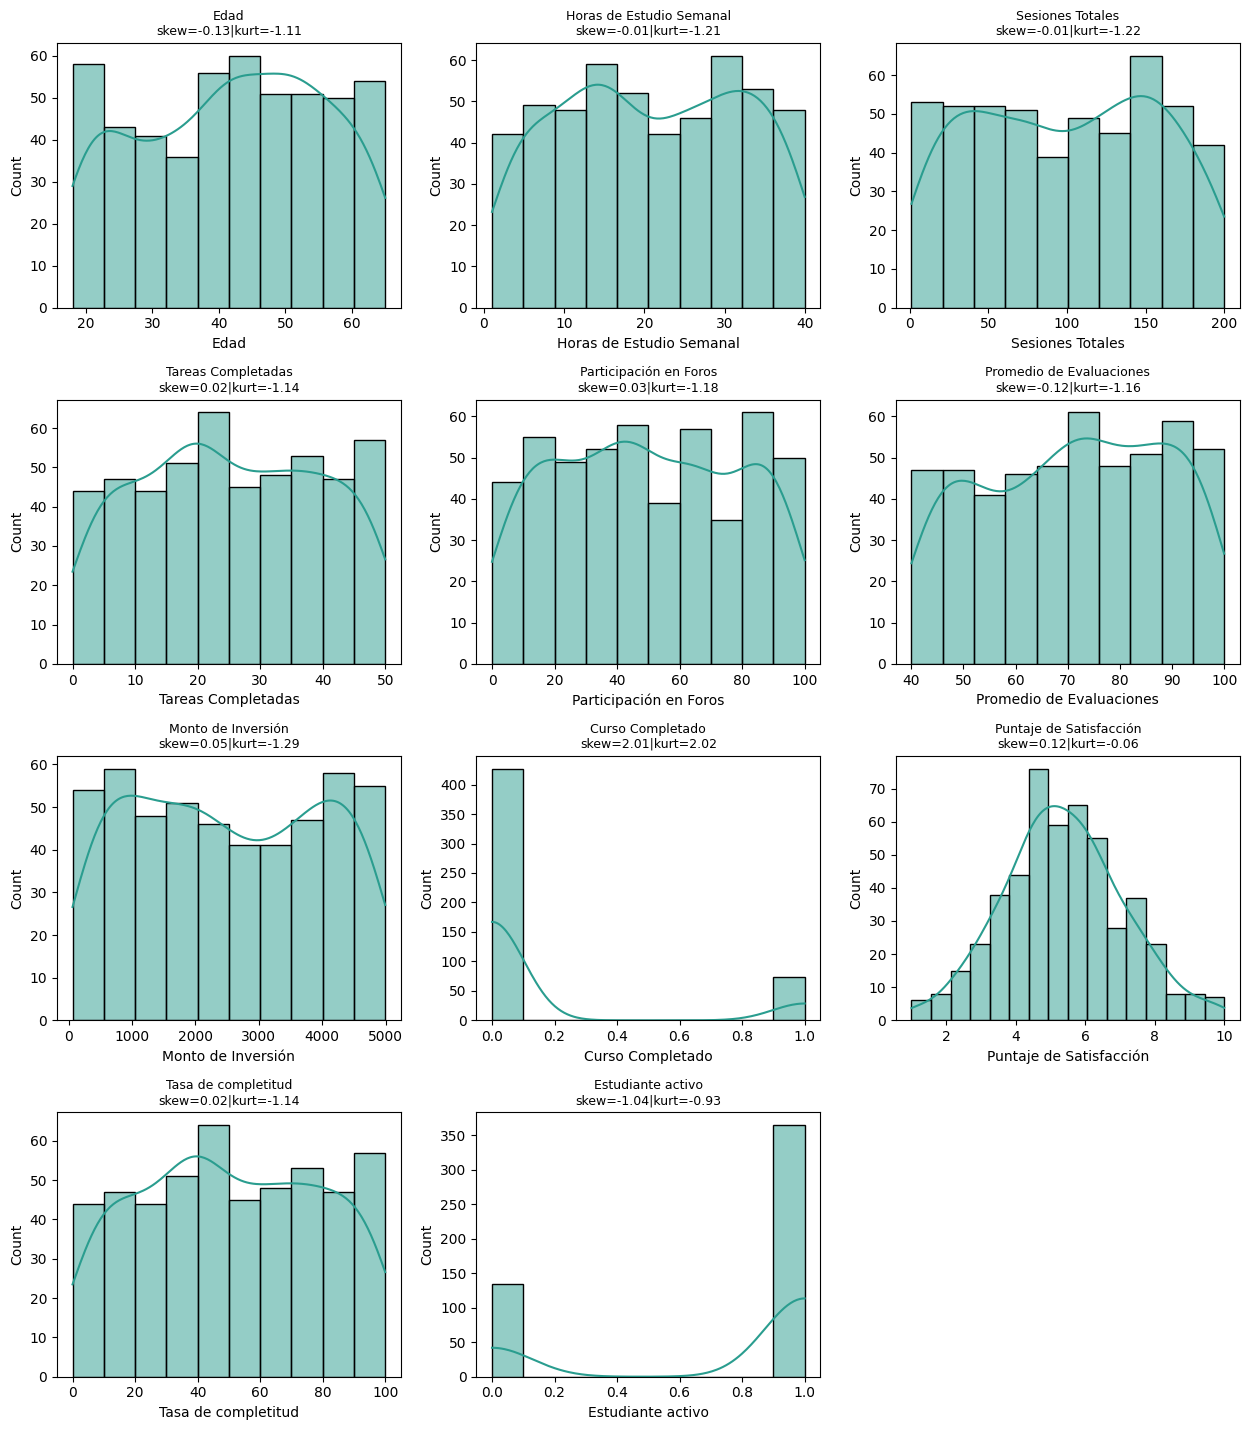

In [34]:
# Distribución de cada variable numérica: 
# histograma + asimetría (skew) + curtosis
col_dist = [c for c in num_col_sin_id if df[c].std() > 0]

# Grilla dinámica
ncol = 3
nrows     = -(-len(col_dist) // ncol)  # techo de la división
fig,axes = plt.subplots(nrows, ncol, figsize=(4.2*ncol,3.6*nrows))
axes      = axes.flatten()
# fin grilla dinámica

for ax, col in zip(axes, col_dist):
    sns.histplot(df[col], kde=True, ax=ax, color='#2A9D8F')
    skew = stats.skew(df[col])
    kurt = stats.kurtosis(df[col])
    ax.set_title(f'{Etiquetas.get(col,col)}\nskew={skew:.2f}|kurt={kurt:.2f}',fontsize=9)
    ax.set_xlabel(Etiquetas.get(col,col))

for ax in axes[len(col_dist):]:  # oculta ejes sobrantes de la grilla, si los hay
    ax.axis('off')

plt.tight_layout()
plt.show()

Casi todas las variables tiene skewness cercano a 0, lo que significa que hay simetría pero curtosis es negativa, por lo que estamos antes una distribución uniforme, mas que ser una distribución normal. Exceptuando a la variable "puntaje satisfacción" que tiene una curtosis cerca a -0.06 si es compatible con una distribución normal y claramente esto se ve en el subplot posicion a33 (inferior derecha)

In [35]:
# Test de normalidad Shapiro-Wilk 
# H₀: la variable se distribuye normal
# H₁: la variable NO provienen de una distribución normal

print("---- Test de normalidad (Shapiro-Wilk): ----")
for col in col_dist:
    stat,p = stats.shapiro(df[col])
    veredicto = "se rechaza H₀ (NO normal)" if p<0.05 else"no hay evidencia para rechazar H₀ (normal)"
    print(f" {col:<25} p={p:.4f} ->{veredicto}")

#scipy.stats.shapiro() usa una versión extendida del shapiro wilk 
#puede manejar muestra de hasta 5000, shapiro común esta recomendado para 50 
# igual se puede usar test de jarque bera, pero el shapiro de stats esta bien empleado para este caso 
# fuente: https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.shapiro.html

---- Test de normalidad (Shapiro-Wilk): ----
 edad                      p=0.0000 ->se rechaza H₀ (NO normal)
 horas_estudio_semanal     p=0.0000 ->se rechaza H₀ (NO normal)
 sesiones_totales          p=0.0000 ->se rechaza H₀ (NO normal)
 tareas_completadas        p=0.0000 ->se rechaza H₀ (NO normal)
 participacion_foros       p=0.0000 ->se rechaza H₀ (NO normal)
 promedio_evaluaciones     p=0.0000 ->se rechaza H₀ (NO normal)
 monto_inversion           p=0.0000 ->se rechaza H₀ (NO normal)
 curso_completado          p=0.0000 ->se rechaza H₀ (NO normal)
 puntaje_satisfaccion      p=0.2504 ->no hay evidencia para rechazar H₀ (normal)
 tasa_completitud          p=0.0000 ->se rechaza H₀ (NO normal)
 estudiante_activo         p=0.0000 ->se rechaza H₀ (NO normal)


El test de Shapiro-Wilk muestra que la mayoría de las variables de este dataset no cumplen el supuesto de normalidad (p < 0.05), por lo que, siguiendo esta referencia, no se reportarán intervalos de confianza ni valores-p para los coeficientes individuales de Pearson. 

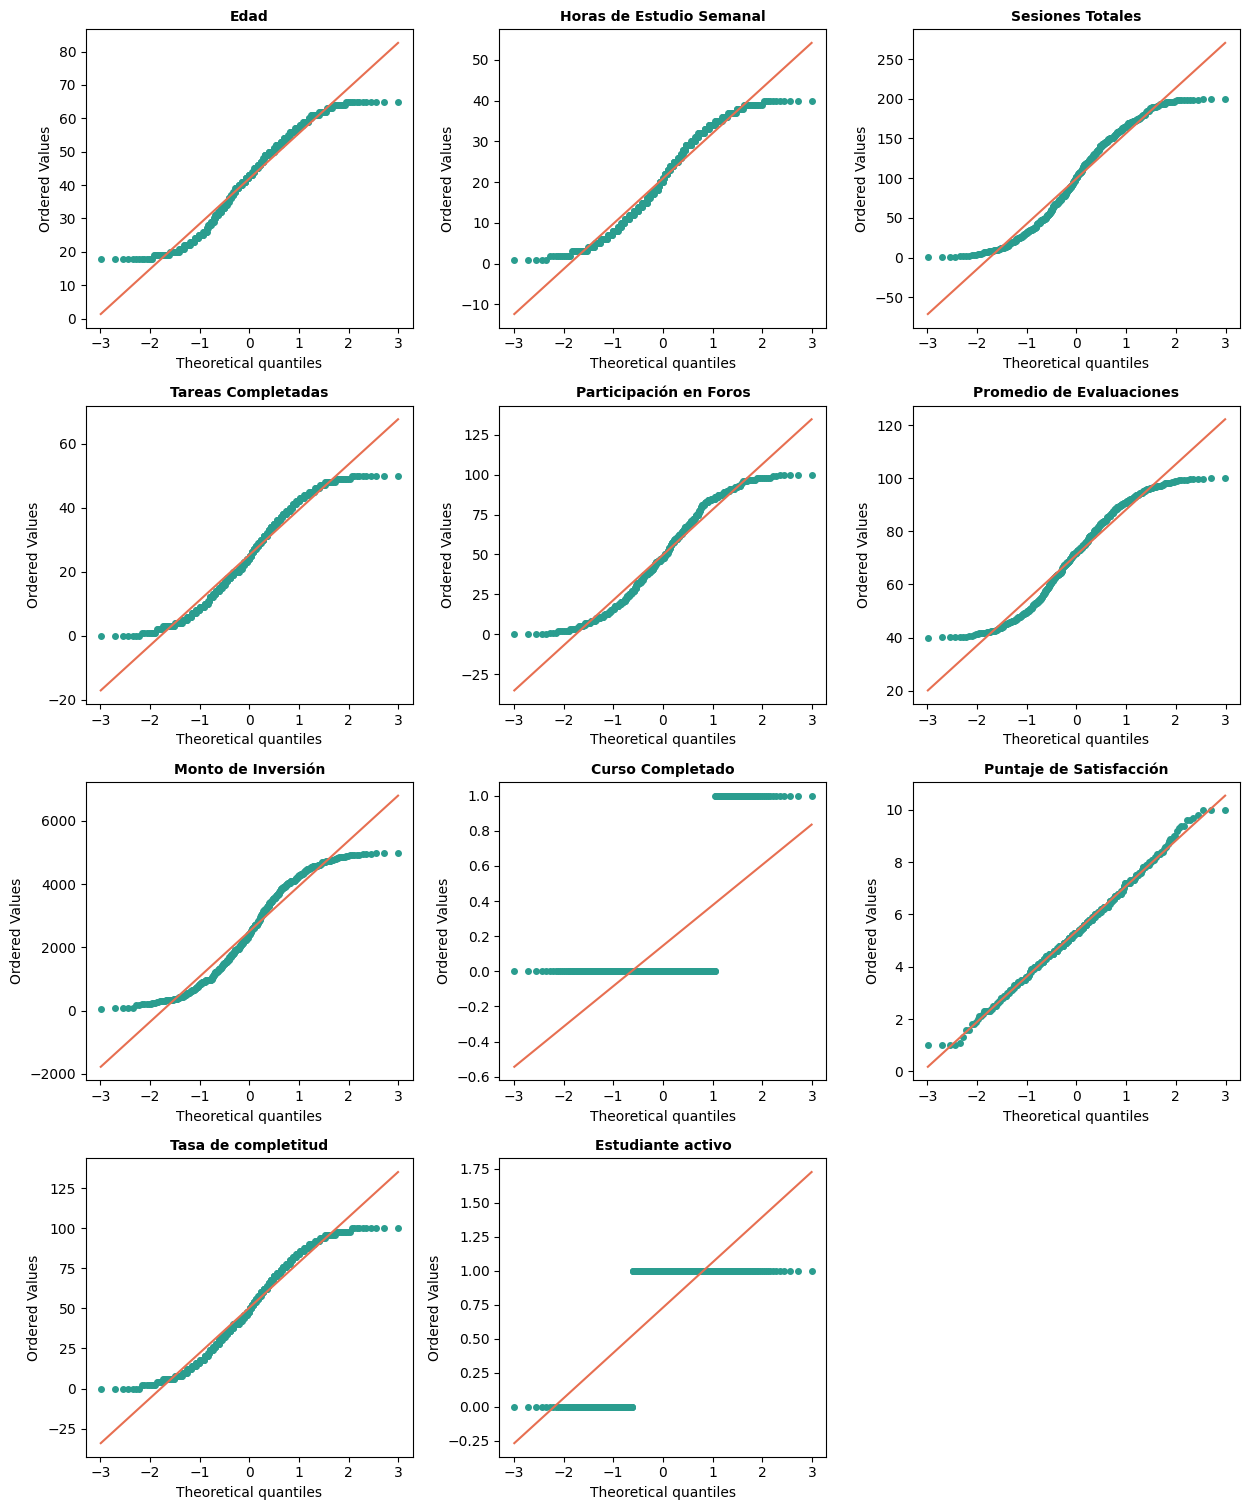

In [36]:
# Q-Q plot:
# compara los cuantiles de la variable contra los de una normal teórica

ncols = 3
nrows = -(-len(col_dist) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.8 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, col_dist):
    stats.probplot(df[col], dist="norm", plot=ax)
    ax.set_title(Etiquetas.get(col, col), fontsize=10, fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('#2A9D8F')
    ax.get_lines()[0].set_markeredgecolor('#2A9D8F')
    ax.get_lines()[0].set_markersize(4)
    ax.get_lines()[1].set_color('#E76F51')

for ax in axes[len(col_dist):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Interpretación:
* para curso completado y estudiante activod se ven dos líneas esto se debe a que esta varibale es binaria.
* para puntaje de satisfacción se ve una lonea recta sin curva pronunciada en los extremos, lo que coincide con shapiro-wilk.
* para el resto de variables se ve la forma de S lo que es consistente con curtosis calculado (negativo), la parte del centro sige la linea recta lo que concuerda con que no hya una asimetría fuerte.



de todo el analisis anterior, gráficos de distribución y test de Shapiro-Wilk es que concluyo que es mas apropiado usar correlación de spearman aun así se deja el código de cálculo de correlación de Pearson. esto debido a que no se cumple el supuesto de normalidad de las variables.

In [37]:
# Correlación entre variables numéricas usando NumPy
#se calcula la correlacion de pearson solo con la finalidad de mostrar el código
# Se excluye 'tareas_totales' por tener varianza cero (desviación estándar = 0)
col_corr = [c for c in num_col_sin_id if df[c].std() > 0]
corr_matrix = np.corrcoef(df[col_corr].values,rowvar=False)
corr_df = pd.DataFrame(corr_matrix, index=col_corr,columns=col_corr)
corr_df.round(2)

,edad,horas_estudio_semanal,sesiones_totales,tareas_completadas,participacion_foros,promedio_evaluaciones,monto_inversion,curso_completado,puntaje_satisfaccion,tasa_completitud,estudiante_activo
edad,1.00,-0.05,0.04,-0.06,-0.04,0.03,-0.11,-0.07,-0.03,-0.06,0.04
horas_estudio_semanal,-0.05,1.00,0.00,0.01,0.02,-0.04,0.04,0.13,0.04,0.01,-0.06
sesiones_totales,0.04,0.00,1.00,-0.03,-0.07,-0.03,0.00,-0.06,-0.05,-0.03,0.77
tareas_completadas,-0.06,0.01,-0.03,1.00,-0.02,-0.06,0.03,0.52,0.16,1.00,-0.03
participacion_foros,-0.04,0.02,-0.07,-0.02,1.00,-0.02,-0.03,-0.06,0.50,-0.02,-0.05
promedio_evaluaciones,0.03,-0.04,-0.03,-0.06,-0.02,1.00,0.03,0.21,0.53,-0.06,-0.06
monto_inversion,-0.11,0.04,0.00,0.03,-0.03,0.03,1.00,0.06,0.05,0.03,-0.00
curso_completado,-0.07,0.13,-0.06,0.52,-0.06,0.21,0.06,1.00,0.45,0.52,-0.07
puntaje_satisfaccion,-0.03,0.04,-0.05,0.16,0.50,0.53,0.05,0.45,1.00,0.16,-0.05
tasa_completitud,-0.06,0.01,-0.03,1.00,-0.02,-0.06,0.03,0.52,0.16,1.00,-0.03


In [38]:
# Correlación de Spearman 
corr_spearman = df[col_corr].corr(method='spearman')
diff = (corr_df - corr_spearman).abs()
print("Diferencia absoluta máxima entre Pearson y Spearman:", diff.values.max().round(3))
print("\n ---- Valores correlación de Spearman ---- ")
corr_spearman.round(2)

Diferencia absoluta máxima entre Pearson y Spearman: 0.029

 ---- Valores correlación de Spearman ---- 


,edad,horas_estudio_semanal,sesiones_totales,tareas_completadas,participacion_foros,promedio_evaluaciones,monto_inversion,curso_completado,puntaje_satisfaccion,tasa_completitud,estudiante_activo
edad,1.00,-0.05,0.03,-0.06,-0.04,0.03,-0.10,-0.07,-0.02,-0.06,0.04
horas_estudio_semanal,-0.05,1.00,0.00,0.01,0.02,-0.05,0.04,0.13,0.03,0.01,-0.06
sesiones_totales,0.03,0.00,1.00,-0.03,-0.07,-0.03,-0.00,-0.06,-0.05,-0.03,0.77
tareas_completadas,-0.06,0.01,-0.03,1.00,-0.02,-0.06,0.03,0.52,0.15,1.00,-0.03
participacion_foros,-0.04,0.02,-0.07,-0.02,1.00,-0.02,-0.03,-0.06,0.48,-0.02,-0.05
promedio_evaluaciones,0.03,-0.05,-0.03,-0.06,-0.02,1.00,0.03,0.20,0.54,-0.06,-0.06
monto_inversion,-0.10,0.04,-0.00,0.03,-0.03,0.03,1.00,0.07,0.04,0.03,-0.01
curso_completado,-0.07,0.13,-0.06,0.52,-0.06,0.20,0.07,1.00,0.42,0.52,-0.07
puntaje_satisfaccion,-0.02,0.03,-0.05,0.15,0.48,0.54,0.04,0.42,1.00,0.15,-0.05
tasa_completitud,-0.06,0.01,-0.03,1.00,-0.02,-0.06,0.03,0.52,0.15,1.00,-0.03


La variables:
* tareas completadas correlaciona fuertemente con curso_completado (0.52)
* participación foros (0.50) y promedio evaluaciones (0.53) correlacionan con puntaje_satisfaccion. 
Estas variables serán más relevantes para los modelos predictivos de las Partes 3 y 4. 

Al comparar con Spearman, la diferencia máxima entre ambos métodos es de apenas ~0.03, lo que confirma que, pese a la no-normalidad detectada, Pearson no está distorsionando las conclusiones en este caso particular.

In [41]:
# para complementar el EDA manual 
profile = ProfileReport(df, title="Reporte EduTech Analytics", explorative=True, progress_bar=False)
alerts = profile.get_description().alerts
print("\n ---- Complementar EDA -----")
print(f"ydata-profiling detectó {len(alerts)} alertas automáticas:\n")
for a in alerts:
    print("-", a)

100%|██████████| 21/21 [00:00<00:00, 144.86it/s]



 ---- Complementar EDA -----
ydata-profiling detectó 13 alertas automáticas:

- [tareas_totales] has a constant value
- [curso_completado] is highly overall correlated with [tareas_completadas] and 1 other fields
- [estudiante_activo] is highly overall correlated with [sesiones_totales]
- [promedio_evaluaciones] is highly overall correlated with [puntaje_satisfaccion]
- [puntaje_satisfaccion] is highly overall correlated with [promedio_evaluaciones]
- [sesiones_totales] is highly overall correlated with [estudiante_activo]
- [tareas_completadas] is highly overall correlated with [curso_completado] and 1 other fields
- [tasa_completitud] is highly overall correlated with [curso_completado] and 1 other fields
- [id_estudiante] is uniformly distributed
- [id_estudiante] has unique values
- [nombre] has unique values
- [tareas_completadas] has 7 (1.4%) zeros
- [tasa_completitud] has 7 (1.4%) zeros


__________
#### 1.2 Visualización Avanzada con Seaborn (1 punto)
* Crea un pairplot que muestre las relaciones entre horas_estudio_semanal, participacion_foros, promedio_evaluaciones y puntaje_satisfaccion, diferenciando por curso_completado
* Genera un heatmap de la matriz de correlación de todas las variables numéricas
* Construye un violinplot comparando la distribución de puntaje_satisfaccion por nivel_educacion

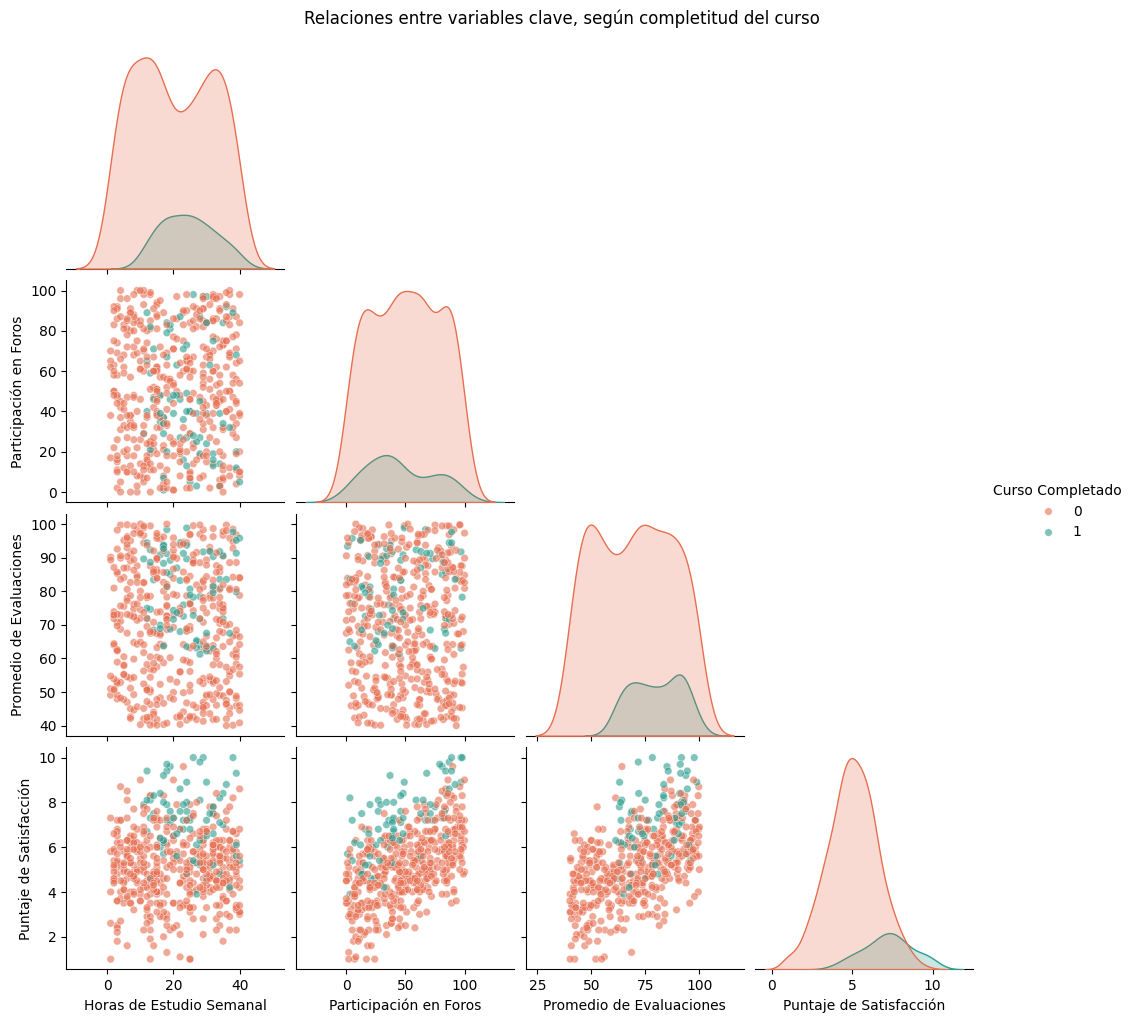

In [ ]:
#&&&&&&&&&&&&&&&    Pairplot   &&&&&&&&&&&&&&&
#relaciones entre variables seleccionadas, diferenciando por curso_completado
g = sns.pairplot(
    df_plot,
    vars=[Etiquetas['horas_estudio_semanal'],Etiquetas['participacion_foros'],
          Etiquetas['promedio_evaluaciones'],Etiquetas['puntaje_satisfaccion']],
    hue=Etiquetas['curso_completado'],
    palette={0:'#E76F51',1:'#2A9D8F'},
    diag_kind='kde',
    corner=True,                    # evita duplicar los gráficos espejo (arriba/abajo de la diagonal)
    plot_kws={'alpha':0.6,'s':30})
g.fig.suptitle('Relaciones entre variables clave, según completitud del curso', y=1.02)
plt.show()

Interpretación del pairplot,  se puede ver que los estudiantes que completan el curso (verde) tienden a tener mayor participacion_foros y promedio evaluaciones, y muestran una distribución de puntaje satisfaccion desplazada hacia valores más altos. 

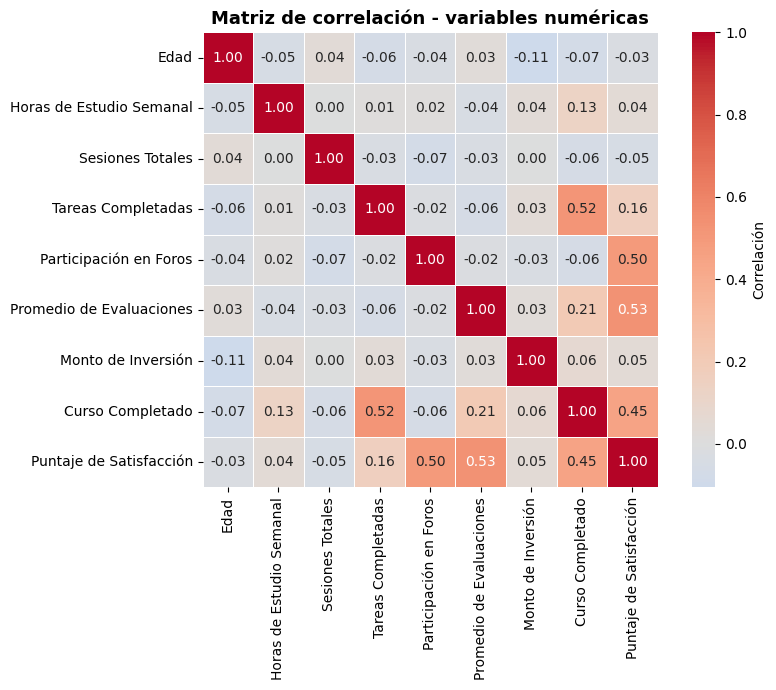

In [ ]:
#&&&&&&&&&&&&&&&    Heatmap   &&&&&&&&&&&&&&&
# matriz de correlación entre variables númerica 
plt.figure(figsize=(9, 7))
corr = df[col_corr].corr().rename(index=Etiquetas, columns=Etiquetas)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
square=True, linewidths=0.5, cbar_kws={'label': 'Correlación'})
plt.title('Matriz de correlación - variables numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Interpretación heatmap
segun nivel de Gignac

- Correlación Fuerte (r > 0.30) (-r cor. fuerte negativa) (r cor. fuerte positiva)
  - Promedio evaluaciones con puntaje de satisfacción: r=0.53
  - Tarea completada con curso completo: 0.52
  - Participacion foros con puntaje satisfacción:r=0.50
  - Curso completado con puntaje satisfacción:r=0.45
- Correlación Mediano (r entre 0.20-0.30)
  - Promedio evaluaciones con curso completado: r=0.21
- Correlación Débil (r entre 0.10-0.20)
  - Tarea completadas con Puntaje de satisfaccion: r=0.16 
  - Horas estudio semanal con curso completado: r=0.13,
  - Edad con monto de inversión: r=0.11
- Correlación Trivial (<0.10)
  - Para el resto de relaciones 


In [ ]:
def clasif_gignac(r):
    r_abs = abs(r)
    if   r_abs > 0.30 : return 'Fuerte'
    elif r_abs >= 0.20: return 'Mediano'
    elif r_abs >= 0.10: return 'Débil'
    else:               return 'Trivial'

pares = corr_spearman.where(np.triu(np.ones(corr_df.shape),k=1).astype(bool)).stack()
pares = pares.sort_values(key=abs,ascending=False)

niveles = {'Fuerte': [], 'Mediano': [], 'Débil': [], 'Trivial': []}
for (a, b), r in pares.items():
    texto = f"{Etiquetas.get(a,a)} con {Etiquetas.get(b,b)}: r={r:+.2f}"
    niveles[clasif_gignac(r)].append(texto)

print("Interpretación heatmap según nivel de Gignac\n")
rangos = {'Fuerte' : '(r > 0.30)', 
          'Mediano': '(r entre 0.20-0.30)',
          'Débil'  : '(r entre 0.10-0.20)', 
          'Trivial': '(<0.10)'}

for nivel in ['Fuerte', 'Mediano', 'Débil', 'Trivial']:
    print(f"- Correlación {nivel} {rangos[nivel]}")
    if nivel == 'Trivial':
        print(f"  - Para el resto de {len(niveles[nivel])} relaciones")
    else:
        for item in niveles[nivel]:
            print(f"  - {item}")

Interpretación heatmap según nivel de Gignac

- Correlación Fuerte (r > 0.30)
  - Promedio de Evaluaciones con Puntaje de Satisfacción: r=+0.54
  - Tareas Completadas con Curso Completado: r=+0.52
  - Participación en Foros con Puntaje de Satisfacción: r=+0.48
  - Curso Completado con Puntaje de Satisfacción: r=+0.42
- Correlación Mediano (r entre 0.20-0.30)
  - Promedio de Evaluaciones con Curso Completado: r=+0.20
- Correlación Débil (r entre 0.10-0.20)
  - Tareas Completadas con Puntaje de Satisfacción: r=+0.15
  - Horas de Estudio Semanal con Curso Completado: r=+0.13
- Correlación Trivial (<0.10)
  - Para el resto de 29 relaciones


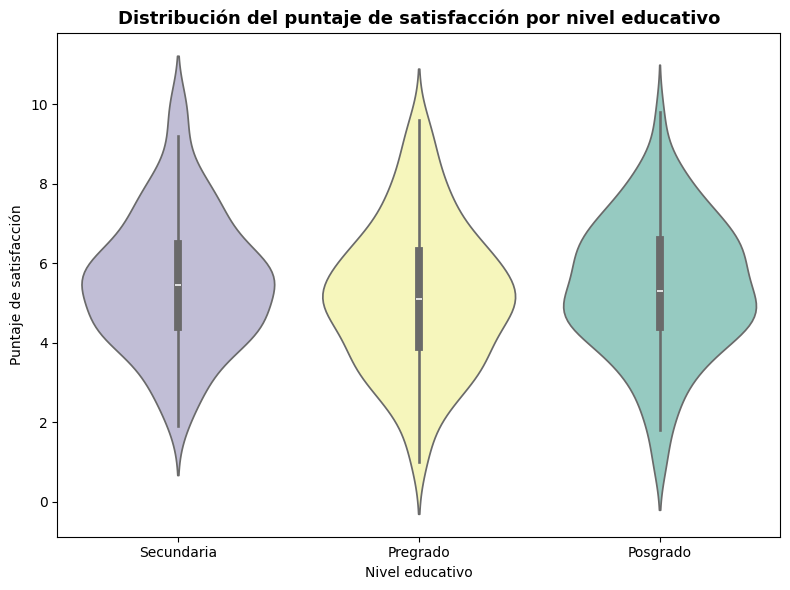

In [ ]:
#&&&&&&&&&&&&&&&    Violinplot   &&&&&&&&&&&&&&&
plt.figure(figsize=(8, 6))
orden = ['Secundaria', 'Pregrado', 'Posgrado']
sns.violinplot(data=df, x='nivel_educacion', y='puntaje_satisfaccion', order=orden,
               hue='nivel_educacion', palette='Set3', legend=False)
plt.title('Distribución del puntaje de satisfacción por nivel educativo', fontsize=13, fontweight='bold')
plt.xlabel('Nivel educativo')
plt.ylabel('Puntaje de satisfacción')
plt.tight_layout()
plt.show()

 Intepretación gráfico de violin:
 Las distribuciones de la variables puntaje de satisfaccion son parecidad entre distinto niveles de eduación, sin un patrón que justifique por si solo la satisfacion del estudiante, lo que concuerda con el heatmap 

#### 1.3 Personalización con Matplotlib (1 punto)

- Crea un gráfico de barras que muestre el promedio de `puntaje_satisfaccion` por `horario_estudio`.
- Personaliza el gráfico con:
  - Título descriptivo y etiquetas de ejes
  - Colores personalizados (paleta a elección)
  - Anotaciones con los valores exactos sobre cada barra
  - Grid horizontal para facilitar lectura
  - Bordes en las barras
- Guarda el gráfico como `satisfaccion_horario.png`.

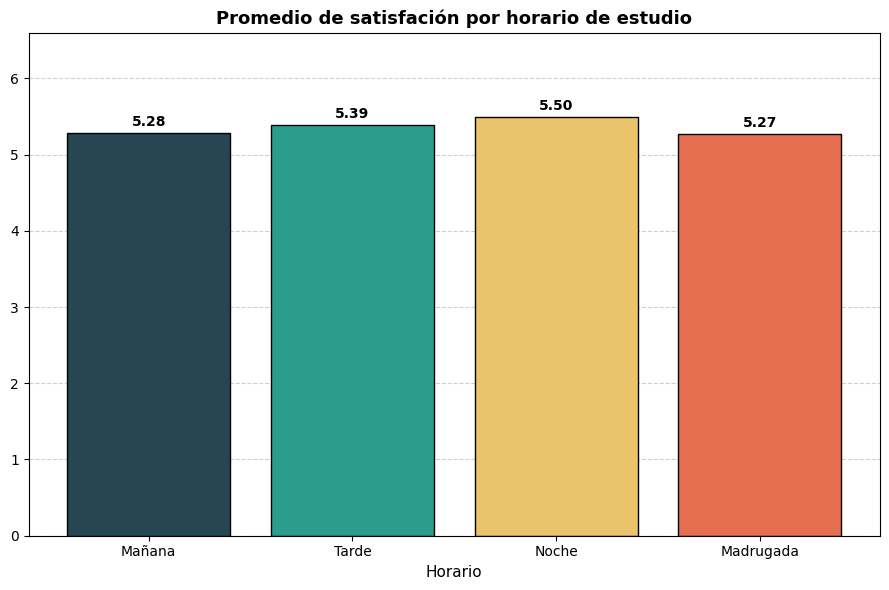

horario_estudio
Mañana       5.284328
Tarde        5.390164
Noche        5.496850
Madrugada    5.265812
Name: puntaje_satisfaccion, dtype: float64


In [ ]:
#&&&&&&&&&&&&&&&    Gráfico de barras    &&&&&&&&&&&&&&&
ord_hor = ['Mañana', 'Tarde', 'Noche', 'Madrugada']
prom    = df.groupby('horario_estudio')['puntaje_satisfaccion'].mean().reindex(ord_hor)

fig,ax = plt.subplots(figsize=(9,6))
colores= ['#264653', '#2A9D8F', '#E9C46A', '#E76F51']
barras = ax.bar(prom.index,prom.values,color=colores,edgecolor='black')
ax.set_title('Promedio de satisfación por horario de estudio',fontsize=13,fontweight='bold')
ax.set_xlabel('Horario',fontsize=11)
ax.yaxis.grid(True,linestyle='--',alpha=0.6)
ax.set_axisbelow(True)
ax.set_ylim(0,prom.max()*1.2)

for barra, valor in zip(barras,prom.values):
    ax.annotate(f'{valor:.2f}',xy=(barra.get_x() + barra.get_width()/2,valor),xytext=(0, 5),textcoords='offset points',ha='center',fontweight='bold')

plt.tight_layout()
plt.savefig('satisfaccion_horario.png', dpi=150, bbox_inches='tight')
plt.show()

print(prom)


Interpretacion gráfico de barras:
La diferencia entre cada horario son muy pequeñas. Elhorario de noche presenta el promedio de satisfación más alto, luego sigue el horario Tarde , el horario Mañana y el horario madrugada.

____________________________
### Parte 2: Preparación de Datos y Feature Engineering (2 puntos)
#### 2.1 Transformación de Variables (1 punto)
* Crea una nueva variable tasa_completitud = (tareas_completadas / tareas_totales) * 100
* Genera variable binaria estudiante_activo = 1 si sesiones_totales > 50, sino 0
* Codifica variables categóricas usando LabelEncoder para variables ordinales y OneHotEncoder para nominales
* Normaliza las variables numéricas usando StandardScaler

In [ ]:
# nuevas variales creada arriba antes de diccionario de etiquetas 

In [ ]:
# Categóricas Ordinales :['nivel_educacion','experiencia_previa']
# Categóricas Nominales :['nombre','genero','pais','dispositivo_principal','horario_estudio','plataforma_origen']


In [ ]:
#&&&&&&&&&&&&&&&   Codificación de variables   &&&&&&&&&&&&&&&
# LabelEncoder para Variable Ordinales (orden jerarquico o lógico)
le= LabelEncoder()
df['experiencia_previa_cod'] = le.fit_transform(df['experiencia_previa'])
print("Mapeo experiencia_previa:",dict(zip(le.classes_, le.transform(le.classes_))))

#&&&&&&&&&&&&&&&   en proceso   &&&&&&&&&&&&&&&

Mapeo experiencia_previa: {'No': np.int64(0), 'Sí': np.int64(1)}


#### 2.2 División y Preparación (1 punto)
* Separa features (X) y variables objetivo (y_clasifi cacion: curso_completado, y_regresion: puntaje_satisfaccion)
* Divide los datos en entrenamiento (70%) y prueba (30%) con random_state=42
* Aplica SMOTE si existe desbalanceo en la variable curso_completado

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&

In [ ]:
#&&&&&&&&&&&&&&&    --   &&&&&&&&&&&&&&&